# Base CNN Training for Posture Classification (FP32)

**Dataset**
- **Input:** 8×8 pressure maps (64 features per sample)
- **Output:** 6 classes (fetus_L, fetus_R, prone, supine, trunk_L, trunk_R)
- **Raw data:** Float32 values in range [0, 213.4]

**Architecture**
- 3 Conv2D layers with BatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: Dense(6, softmax)

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 10

## Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Keras 3
import keras
import keras_tuner
from keras import layers
from keras import regularizers
from keras import optimizers
from keras.utils import to_categorical

# Scikit-learn for metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

## Data Loading

In [43]:
# Dataset paths
dataset_dir = Path('../dataset/output')
train_file = dataset_dir / 'train_raw.npz'
val_file = dataset_dir / 'val_raw.npz'
test_file = dataset_dir / 'test_raw.npz'

# Load datasets
train_data = np.load(train_file, allow_pickle=True)
val_data = np.load(val_file, allow_pickle=True)
test_data = np.load(test_file, allow_pickle=True)

# Extract features and labels
X_train_raw = train_data['data']
y_train_raw = train_data['labels']

X_val_raw = val_data['data']
y_val_raw = val_data['labels']

X_test_raw = test_data['data']
y_test_raw = test_data['labels']

print(f"\nDataset shapes:")
print(f"  Train: {X_train_raw.shape}, labels: {y_train_raw.shape}")
print(f"  Val:   {X_val_raw.shape}, labels: {y_val_raw.shape}")
print(f"  Test:  {X_test_raw.shape}, labels: {y_test_raw.shape}")


Dataset shapes:
  Train: (76, 64), labels: (76,)
  Val:   (69, 64), labels: (69,)
  Test:  (47, 64), labels: (47,)


## Data Preprocessing

In [44]:
# Encode labels as integers 0-5
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train_raw)
y_val_int = label_encoder.transform(y_val_raw)
y_test_int = label_encoder.transform(y_test_raw)

print(f"Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# One-hot encode labels
num_classes = 6
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print(f"\nOne-hot encoded shape: {y_train.shape[1]}")

Label encoding:
  fetus_L -> 0
  fetus_R -> 1
  prone -> 2
  supine -> 3
  trunk_L -> 4
  trunk_R -> 5

One-hot encoded shape: 6


In [45]:
# Reshape data from (N, 64) to (N, 8, 8, 1)
X_train = X_train_raw.reshape(-1, 8, 8, 1).astype('float32')
X_val = X_val_raw.reshape(-1, 8, 8, 1).astype('float32')
X_test = X_test_raw.reshape(-1, 8, 8, 1).astype('float32')

print(f"Reshaped data:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\nData range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Data dtype: {X_train.dtype}")

Reshaped data:
  Train: (76, 8, 8, 1)
  Val:   (69, 8, 8, 1)
  Test:  (47, 8, 8, 1)

Data range: [0.0000, 213.4010]
Data dtype: float32


## Base Model Definition (FP32)

In [ ]:
def create_base_model(input_shape=(8, 8, 1), num_classes=6):
    """
    Create best CNN model for posture classification.
    
    Architecture:
        - Input: (8, 8, 1) pressure map
        - Conv2D(16) + BN + ReLU
        - Conv2D(16) + BN + ReLU
        - Conv2D(24) + BN + ReLU
        - MaxPool(2,2)
        - GlobalAveragePooling
        - Dense(6) + Softmax
    
    Args:
        input_shape: Shape of input tensor (H, W, C)
        num_classes: Number of output classes
    
    Returns:
        Keras Model instance
    """
    # Input layer
    inputs = keras.Input(shape=input_shape, name='pressure_map')
    
    # Conv Block 1: 16 filters
    x = layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_1'
    )(inputs)
    x = layers.BatchNormalization(name='bn_conv_1')(x)
    x = layers.Activation('relu', name='conv_act_1')(x)
    
    # Conv Block 2: 16 filters
    x = layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_2'
    )(x)
    x = layers.BatchNormalization(name='bn_conv_2')(x)
    x = layers.Activation('relu', name='conv_act_2')(x)
    
    # Conv Block 3: 24 filters
    x = layers.Conv2D(
        filters=24,
        kernel_size=(3, 3),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_3'
    )(x)
    x = layers.BatchNormalization(name='bn_conv_3')(x)
    x = layers.Activation('relu', name='conv_act_3')(x)
    
    # Single MaxPooling (applied once, not after every layer)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool_1')(x)
    
    # Global Average Pooling (reduces parameters vs Flatten)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='posture_classifier_base')
    
    return model

# Create base model
base_model = create_base_model()
base_model.summary()

Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,278 (24.52 KB)

 Trainable params: 6,166 (24.09 KB)

 Non-trainable params: 112 (448.00 B)

In [47]:
# Taken from part6_cnns.ipynb (also used in Scr_1_TensorFlowCNN.py)

for layer in base_model.layers:
    if layer.__class__.__name__ in ['Conv2D', 'Dense']:
        w = layer.get_weights()[0]
        layersize = np.prod(w.shape)
        print("{}: {}".format(layer.name, layersize))  # 0 = weights, 1 = biases
        if layersize > 4096:  # assuming that shape[0] is batch, i.e., 'None'
            print("Layer {} is too large ({}), are you sure you want to train?".format(layer.name, layersize))

conv_1: 144
conv_2: 2304
conv_3: 3456
output: 144


## Training Configuration

In [ ]:
# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_base_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


## Base Model Training

In [49]:
# Compile base model
base_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
# Training hyperparameters
batch_size = 32
max_epochs = 100

In [51]:
# Train the model
start_time = time.time()

base_history = base_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time/60:.2f} minutes")

Epoch 1/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.1562 - loss: 2.2040


Epoch 1: val_loss improved from None to 5.79299, saving model to best_base_model.keras

Epoch 1: finished saving model to best_base_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.1447 - loss: 2.3245 - val_accuracy: 0.1884 - val_loss: 5.7930 - learning_rate: 0.0010
Epoch 2/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3438 - loss: 1.7462
Epoch 2: val_loss improved from 5.79299 to 4.47511, saving model to best_base_model.keras

Epoch 2: finished saving model to best_base_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3289 - loss: 1.8628 - val_accuracy: 0.1884 - val_loss: 4.4751 - learning_rate: 0.0010
Epoch 3/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4688 - loss: 1.5258
Epoch 3: val_loss improved from 4.47511 to 3.72930, saving model to best_base_model.keras

Epoch 3: finished saving model to best_base_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4211 - loss: 1.5942 - val_accuracy: 0.1884 - val_loss: 3.7293 -

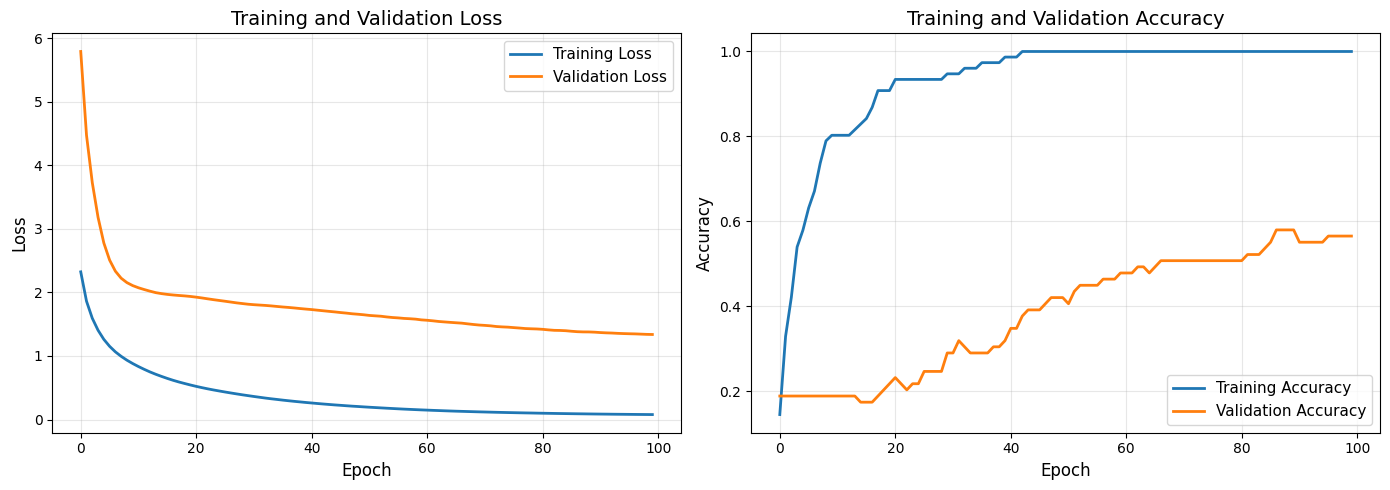

In [52]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(base_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(base_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(base_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(base_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Optimized Base Model

Hyperparameter optimization (KerasTuner)

In [53]:
def build_model(hp):
    """
    Build CNN model with hyperparameter tuning for all layers.
    
    Args:
        hp: HyperParameters object from keras_tuner
    
    Returns:
        Compiled Keras Model
    """
    # Tunable hyperparameters for each conv layer
    filters_1 = hp.Int('filters_1', min_value=8, max_value=32, step=8)
    filters_2 = hp.Int('filters_2', min_value=8, max_value=32, step=8)
    filters_3 = hp.Int('filters_3', min_value=16, max_value=64, step=8)
    
    # Tunable kernel size
    kernel_size = hp.Choice('kernel_size', values=[3, 5])
    
    # Tunable learning rate
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0001])
    
    # Input layer
    inputs = keras.Input(shape=(8, 8, 1), name='pressure_map')
    
    # Conv Block 1
    x = layers.Conv2D(
        filters=filters_1,
        kernel_size=(kernel_size, kernel_size),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_1'
    )(inputs)
    x = layers.BatchNormalization(name='bn_conv_1')(x)
    x = layers.Activation('relu', name='conv_act_1')(x)
    
    # Conv Block 2
    x = layers.Conv2D(
        filters=filters_2,
        kernel_size=(kernel_size, kernel_size),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_2'
    )(x)
    x = layers.BatchNormalization(name='bn_conv_2')(x)
    x = layers.Activation('relu', name='conv_act_2')(x)
    
    # Conv Block 3
    x = layers.Conv2D(
        filters=filters_3,
        kernel_size=(kernel_size, kernel_size),
        kernel_initializer='lecun_uniform',
        kernel_regularizer=regularizers.l1(1e-4),
        use_bias=False,
        name='conv_3'
    )(x)
    x = layers.BatchNormalization(name='bn_conv_3')(x)
    x = layers.Activation('relu', name='conv_act_3')(x)
    
    # MaxPooling
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool_1')(x)
    
    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Output layer
    outputs = layers.Dense(6, activation='softmax', name='output')(x)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='posture_classifier_tuned')
    
    # Compile with tunable learning rate
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [100]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10)

Reloading Tuner from ./untitled_project/tuner0.json


In [101]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
best_model = tuner.get_best_models()[0]

best_model.summary()

Trial 10 Complete [00h 00m 01s]

Best val_loss So Far: 2.0628745555877686
Total elapsed time: 00h 18m 03s


/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 32)       │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,558 (29.52 KB)

 Trainable params: 7,430 (29.02 KB)

 Non-trainable params: 128 (512.00 B)

## Optimized Model Training

In [102]:
# Compile optimized base model
best_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [103]:
# Training hyperparameters
batch_size = 32
max_epochs = 100

In [109]:
# Train the model
start_time = time.time()

best_history = best_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val),
    # callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time/60:.2f} minutes")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4342 - loss: 1.5342 - val_accuracy: 0.2029 - val_loss: 1.9737
Epoch 2/100
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4688 - loss: 1.3515

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4474 - loss: 1.5139 - val_accuracy: 0.2174 - val_loss: 1.9597
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4737 - loss: 1.4880 - val_accuracy: 0.2174 - val_loss: 1.9469
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4737 - loss: 1.4605 - val_accuracy: 0.2174 - val_loss: 1.9343
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4737 - loss: 1.4335 - val_accuracy: 0.2609 - val_loss: 1.9215
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5000 - loss: 1.4086 - val_accuracy: 0.2609 - val_loss: 1.9095
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 1.3847 - val_accuracy: 0.2464 - val_loss: 1.8970
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5526 - loss: 1.3609 - val_accuracy: 0.2464 - val_loss: 1.8858
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5789 - loss: 1.3379 - val_accuracy: 0.2609 - val_loss: 1.8755
Epoc

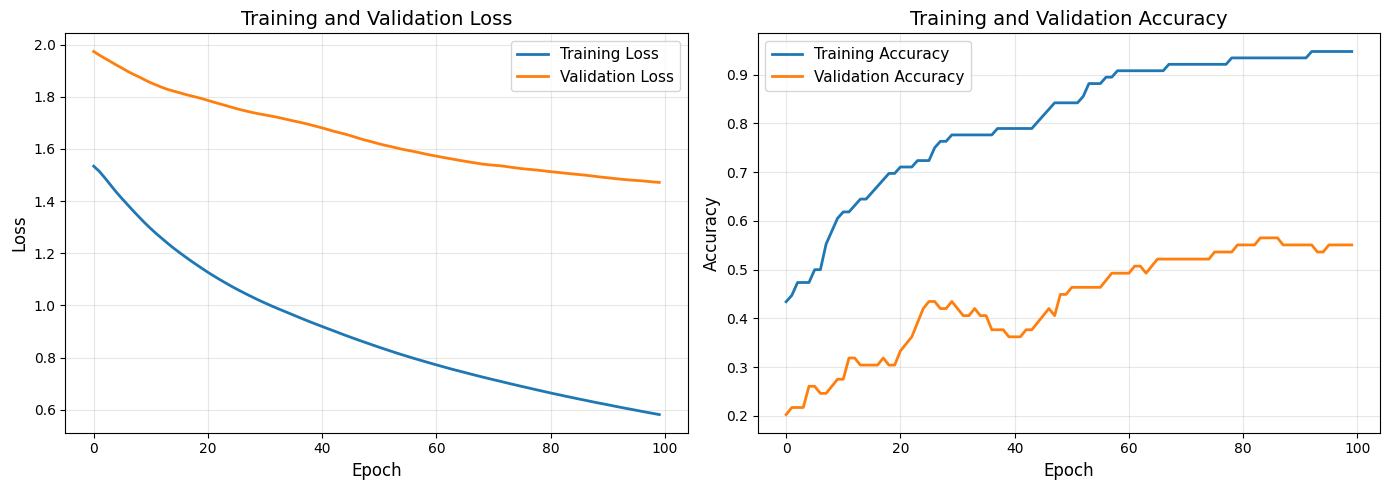

In [110]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(best_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(best_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(best_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(best_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Evaluation

Total metric

In [111]:
# Evaluate on test set

# Base model
base_test_loss, base_test_accuracy = base_model.evaluate(X_test, y_test, verbose=0)

print("\nTest Base Model:")
print(f"  Loss: {base_test_loss:.4f}")
print(f"  Accuracy: {base_test_accuracy*100:.2f}%")

# Best model
best_test_loss, best_test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)

print("\nTest Best Model:")
print(f"  Loss: {best_test_loss:.4f}")
print(f"  Accuracy: {best_test_accuracy*100:.2f}%")


Test Base Model:
  Loss: 1.1725
  Accuracy: 68.09%

Test Best Model:
  Loss: 1.4979
  Accuracy: 46.81%


Metrics per classification

In [112]:
# Get predictions
y_pred_proba = base_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print("="*70)
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_,
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

     fetus_L     0.6000    0.7500    0.6667         8
     fetus_R     0.6667    0.5714    0.6154         7
       prone     0.6364    0.8750    0.7368         8
      supine     0.5455    0.7500    0.6316         8
     trunk_L     1.0000    0.3750    0.5455         8
     trunk_R     1.0000    0.7500    0.8571         8

    accuracy                         0.6809        47
   macro avg     0.7414    0.6786    0.6755        47
weighted avg     0.7430    0.6809    0.6768        47



## Model Saving

In [113]:
# Save base model in Keras 3 format
base_model_path = 'posture_classifier_base.keras'
base_model.save(base_model_path)

print(f"Base model saved to: {base_model_path}")
print(f"Model saved in Keras 3 native format (.keras)")

# Verify saved model
loaded_model = keras.models.load_model(base_model_path)
print(f"\nVerification:")
print(f"  Loaded successfully: {loaded_model is not None}")
print(f"  Model name: {loaded_model.name}")
print(f"  Total parameters: {loaded_model.count_params():,}")

Base model saved to: posture_classifier_base.keras
Model saved in Keras 3 native format (.keras)

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 6,278
